Adición de ruido gaussiano en proporción a la información nutricional.

In [ ]:
import pandas as pd

# Ruta del archivo en tu Drive
ruta_excel = '.../data/data_proceseed/df_imputado.xlsx'

# Leer el archivo Excel
df_imputado = pd.read_excel(ruta_excel)

In [ ]:
##EVITAMOS QUE SE GENERE RUIDO CON VALORES NEGATIVOS

import numpy as np

# Copia del DataFrame original
df_ruido = df_imputado.copy()

# Solo columnas nutricionales
columnas_nutricionales = [
    'proteina_dumas', 'fibra', 'fosfolipidos', 'grasa', 'tyr','humedad',  'ph' ] # solo nutricionales

# Agregar ruido proporcional (5% del std), evitando negativos
for col in columnas_nutricionales:
    std = df_ruido[col].std()
    if std == 0 or np.isnan(std):
        continue
    ruido = np.random.normal(loc=0, scale=0.05 * std, size=df_ruido.shape[0])
    df_ruido[col] += ruido
    df_ruido[col] = df_ruido[col].clip(lower=0)  # Evita valores negativos

In [ ]:
duplicadas = df_ruido.columns[df_ruido.columns.duplicated()].tolist()
print("Columnas duplicadas:", duplicadas)


Columnas duplicadas: ['TA_porcentaje_']


In [ ]:
df_ruido = df_ruido.loc[:, ~df_ruido.columns.duplicated()]


In [ ]:
df_ruido

,O2_am,pH_am,T_am,ph,humedad,proteina_dumas,fibra,fosfolipidos,grasa,tyr,...,GPsem,GPacu,CAsem,CAacum,AlimentoReal_kg_,Biomasa_kg_,TA_porcentaje_,TC_porcentaje_,ROI,ConsumoAlimento_g_cam_dia_
0,6.074,8.042,27.08,7.735646,10.749703,36.477572,1.760608,1.812587,6.980954,1.240187,...,1.608913,5.566667,36.524189,118.887665,0.004044,0.239205,1.2,1.0,2.246356,0.457838
1,6.168,8.030,27.06,7.782733,10.812439,36.453599,1.795739,1.806319,6.859886,1.235057,...,1.572554,5.816667,41.454380,133.496395,0.003688,0.249980,1.2,1.0,2.235070,0.417583
2,6.182,8.008,27.06,7.789720,10.776186,36.449656,1.788271,1.798313,6.923643,1.236190,...,1.631638,6.091667,39.354274,129.785284,0.003482,0.260070,1.2,1.0,2.496526,0.394248
3,6.122,8.020,27.10,7.811984,10.790846,36.519850,1.775650,1.822472,6.900787,1.235420,...,1.586188,5.350000,34.354921,124.135534,0.003985,0.259874,1.2,1.0,2.587864,0.451177
4,6.116,8.058,27.04,7.784756,10.804792,36.503919,1.785353,1.830530,6.925191,1.234383,...,1.495289,5.758333,41.329319,143.098680,0.003617,0.273979,1.2,1.0,2.556339,0.405947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7316,6.262,7.850,30.00,7.738914,12.459132,36.952345,1.789327,1.265866,8.028889,1.304584,...,1.640250,4.794821,590.884506,1417.033816,0.076063,1.548434,1.1,1.0,0.068101,0.478709
7317,5.978,7.606,30.94,7.721967,12.394191,37.003608,1.780126,1.267404,7.998055,1.304485,...,2.737250,7.532071,634.914206,1975.885423,0.084747,1.978746,1.1,1.0,0.626959,0.534610
7318,6.280,7.734,30.36,7.614376,12.393539,36.966476,1.789555,1.264752,8.068521,1.304942,...,2.895000,10.427071,693.147571,2584.285765,0.090606,2.430801,1.1,1.0,0.756386,0.573180
7319,6.292,7.850,30.00,7.778413,12.333310,36.919208,1.788620,1.237154,8.122531,1.306975,...,2.015000,12.442071,736.655124,3230.335302,0.094244,2.741336,1.1,1.0,0.739522,0.597936


In [ ]:
#guardando df_ruido
# Guardar en Excel
ruta = '.../data/data_proceseed/df_ruido.xlsx'
df_ruido.to_excel(ruta)
print(f"✅ Resumen guardado en: {ruta}")

✅ Resumen guardado en: /content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/df_ruido.xlsx


Revisando la correlacion luego de agregar ruido

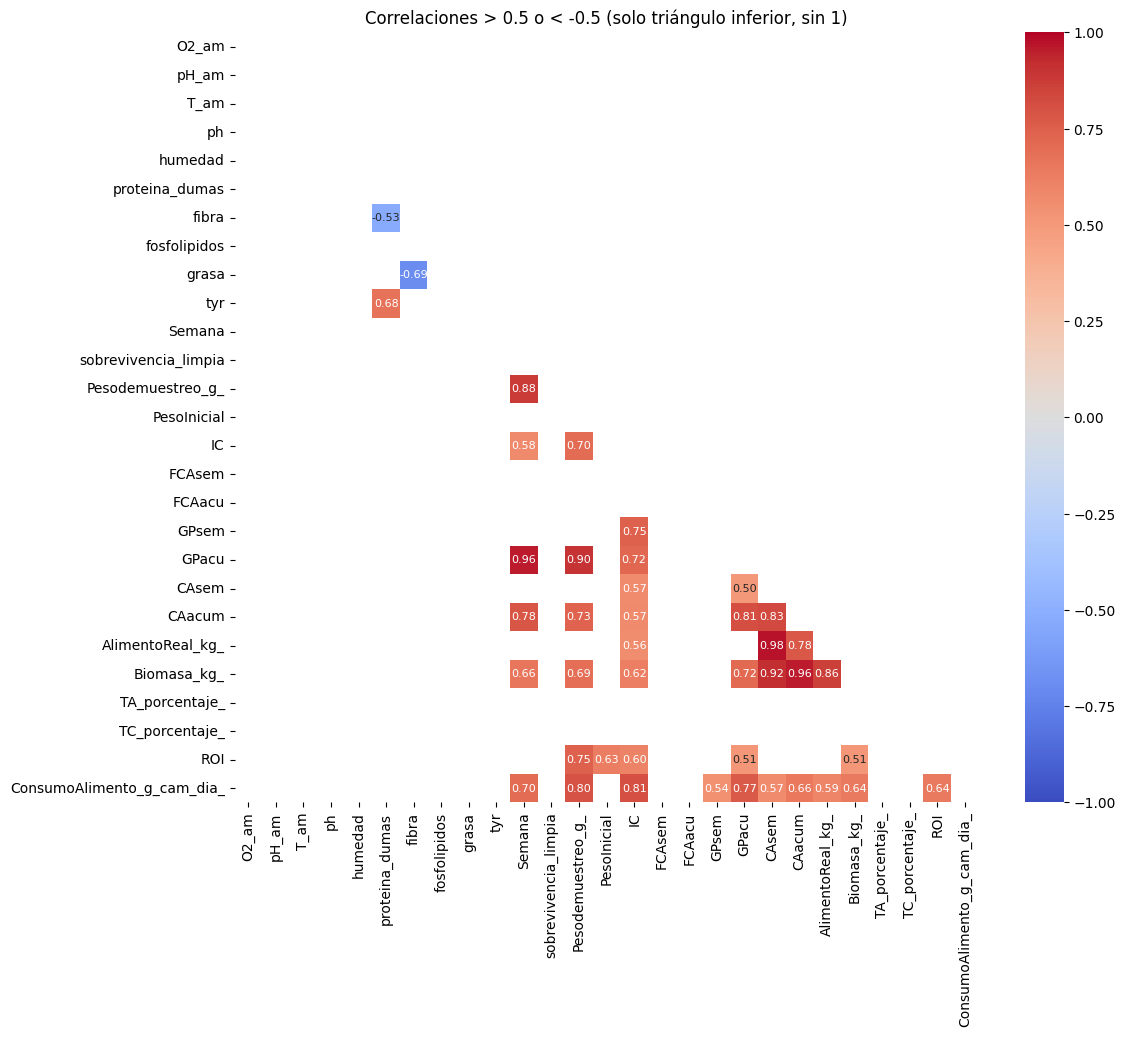

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular matriz de correlación
corr_matrix = df_ruido.corr()

# Crear máscara para ocultar valores fuera del rango deseado y diferentes de 1
masked_corr = corr_matrix.where(
    ((corr_matrix > 0.5) | (corr_matrix < -0.5)) & (corr_matrix != 1)
)

# Crear máscara para el triángulo superior
mask_upper = np.triu(np.ones_like(masked_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    masked_corr,
    annot=True,
    annot_kws={"size": 8},
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    mask=mask_upper | masked_corr.isnull(),  # combinar con la máscara original
    cbar=True
)
plt.title("Correlaciones > 0.5 o < -0.5 (solo triángulo inferior, sin 1)")
plt.show()


Revision resumen dataframe con ruido agregado

In [ ]:
# Creamos una función que muestre los rangos y otras métricas de todas las columnas numéricas.

def resumen_columnas(df):
    resumen = pd.DataFrame({
        'min': df.min(numeric_only=True),
        'max': df.max(numeric_only=True),
        'rango': df.max(numeric_only=True) - df.min(numeric_only=True),
        'n_registros': len(df),
        'n_nulos': df.isna().sum(),
        'n_0': (df == 0).sum()
    })

    return resumen

# Solicitar al usuario que vuelva a cargar df_cruzado si no lo tiene disponible
resumen = resumen_columnas(df_ruido) if 'df_ruido' in globals() else "Por favor, vuelve a cargar df_cruzado."
resumen

,min,max,rango,n_registros,n_nulos,n_0
O2_am,5.000000,7.600000,2.600000,7321,0,0
pH_am,7.250000,8.690000,1.440000,7321,0,0
T_am,23.700000,33.500000,9.800000,7321,0,0
ph,5.814702,8.729712,2.915009,7321,0,0
humedad,9.672564,12.587069,2.914505,7321,0,0
proteina_dumas,33.844461,42.359386,8.514925,7321,0,0
fibra,0.926483,3.190403,2.263920,7321,0,0
fosfolipidos,0.584944,2.248244,1.663300,7321,0,0
grasa,5.203492,10.430821,5.227329,7321,0,0
tyr,1.048389,1.461620,0.413231,7321,0,0


## Aplicando red adversaria generativa (GAN)

In [ ]:
# PASO 1: Preparar el entorno
!pip install torch torchvision

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Copia de df_ruido para ajustarlo sin modificar el original
df_ruido_adj = df_ruido.copy()

# PASO EXTRA: Forzar el rango mínimo en T_am para entrenamiento del scaler
if 'T_am' in df_ruido.columns:
    fila_ficticia = {col: df_ruido[col].mean() for col in df_ruido.columns}
    fila_ficticia['T_am'] = 20
    df_ruido_adj = pd.concat([df_ruido_adj, pd.DataFrame([fila_ficticia])], ignore_index=True)

# PASO 2: Normalizar los datos con rango ajustado
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_ruido_adj)

# Convertimos a tensor solo los datos originales (sin la fila ficticia)
data_tensor = torch.tensor(data_scaled[:len(df_ruido)], dtype=torch.float32)

# PASO 3: Definir la GAN
input_dim = data_tensor.shape[1]
latent_dim = 10

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim),
            nn.ReLU()  # 👈 Garantiza salidas >= 0
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# PASO 4: Entrenamiento de la GAN
generator = Generator()
discriminator = Discriminator()
criterion = nn.BCELoss()
lr = 0.0002

g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr)

epochs = 5000
batch_size = 64

for epoch in range(epochs):
    # Entrenamiento del discriminador
    real_data = data_tensor[torch.randint(0, len(data_tensor), (batch_size,))]
    fake_z = torch.randn(batch_size, latent_dim)
    fake_data = generator(fake_z)

    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)

    d_loss_real = criterion(discriminator(real_data), real_labels)
    d_loss_fake = criterion(discriminator(fake_data.detach()), fake_labels)
    d_loss = d_loss_real + d_loss_fake

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # Entrenamiento del generador
    g_loss = criterion(discriminator(fake_data), real_labels)
    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: D_loss={d_loss.item():.4f}, G_loss={g_loss.item():.4f}")

# PASO 5: Generar nuevos datos
z = torch.randn(1000, latent_dim)
fake_samples = generator(z).detach().numpy()

# Clip antes de desnormalizar
fake_samples = np.clip(fake_samples, a_min=0, a_max=1)

# Desnormalizar
fake_samples = scaler.inverse_transform(fake_samples)

# Clip final general
fake_samples = np.clip(fake_samples, a_min=0, a_max=None)

# PASO EXTRA: aplicar restricciones por columna
restricciones = {
    'T_am': (20, 34),     # T_am en 20–34 °C
    'T_pm': (20, 34),     # T_pm si existe
    'TC_porcentaje_': (0, 1),
    'Supervivencia': (0, 100),
    'ROI': (0, None)
}

for col, (min_val, max_val) in restricciones.items():
    if col in df_ruido.columns:
        idx = df_ruido.columns.get_loc(col)
        fake_samples[:, idx] = np.clip(fake_samples[:, idx], a_min=min_val, a_max=max_val)

# Crear DataFrame sintético
df_sintetico_gan = pd.DataFrame(fake_samples, columns=df_ruido.columns)

# PASO 6: Combinar y guardar
df_augmented = pd.concat([df_ruido, df_sintetico_gan], ignore_index=True)



Epoch 0: D_loss=1.3822, G_loss=0.6419
Epoch 1000: D_loss=1.3517, G_loss=0.6915
Epoch 2000: D_loss=1.3671, G_loss=0.7212
Epoch 3000: D_loss=1.3895, G_loss=0.6834
Epoch 4000: D_loss=1.3540, G_loss=0.7476


In [ ]:
ruta_guardado = '.../data/data_proceseed/df_augmented_gan.xlsx'
df_augmented.to_excel(ruta_guardado, index=False)
print(f"✅ Archivo guardado: {ruta_guardado}")



✅ Archivo guardado: /content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/df_augmented_gan.xlsx


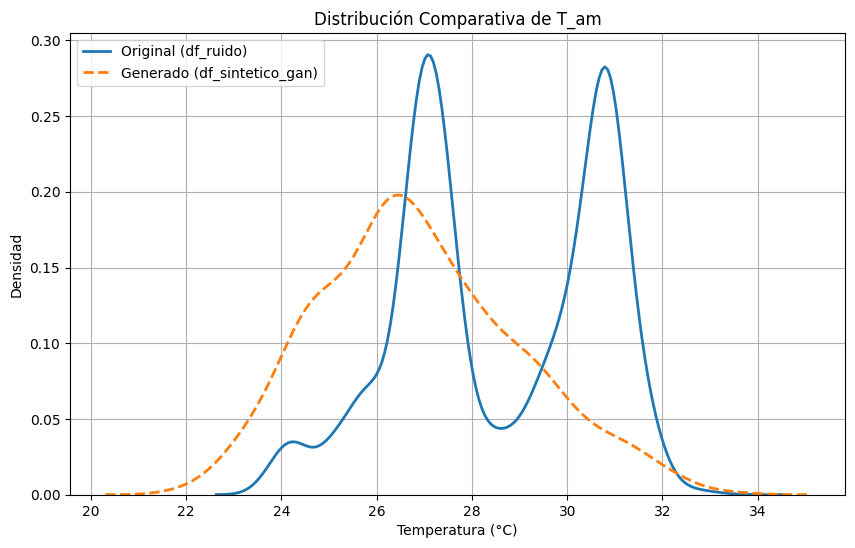

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Verificamos que exista la columna
if 'T_am' in df_sintetico_gan.columns and 'T_am' in df_ruido.columns:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df_ruido['T_am'], label='Original (df_ruido)', linewidth=2)
    sns.kdeplot(df_sintetico_gan['T_am'], label='Generado (df_sintetico_gan)', linewidth=2, linestyle='--')
    plt.title('Distribución Comparativa de T_am')
    plt.xlabel('Temperatura (°C)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("❌ La columna 'T_am' no existe en uno de los dataframes.")


PCA con comparación real vs. sintético

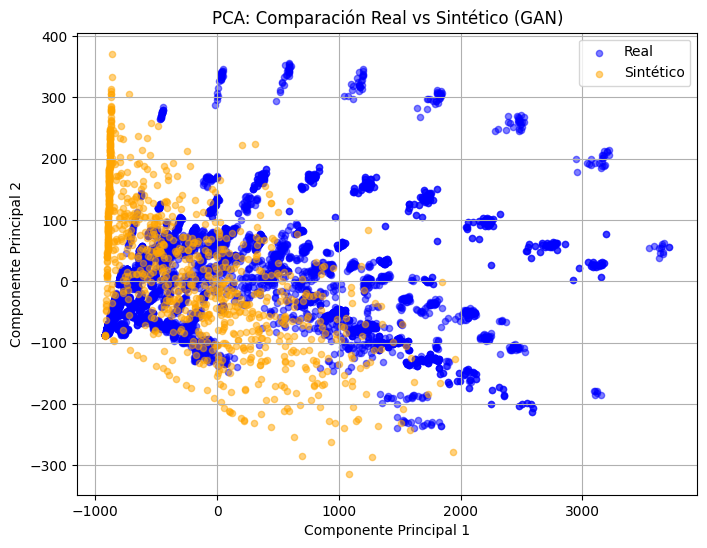

Varianza explicada por PC1 y PC2: 99.92%


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Crear una etiqueta para identificar real vs sintético
df_real = df_ruido.copy()
df_real['origen'] = 'Real'
df_sint = df_sintetico_gan.copy()
df_sint['origen'] = 'Sintético'

# Combinar
df_comp = pd.concat([df_real, df_sint], ignore_index=True)

# Seleccionar solo variables numéricas
X = df_comp.select_dtypes(include=[np.number]).drop(columns=['origen'], errors='ignore')

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# DataFrame con componentes
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['origen'] = df_comp['origen'].values

# Graficar
plt.figure(figsize=(8,6))
for label, color in [('Real', 'blue'), ('Sintético', 'orange')]:
    subset = df_pca[df_pca['origen'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, alpha=0.5, s=20, color=color)

plt.title('PCA: Comparación Real vs Sintético (GAN)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.show()

# Mostrar varianza explicada
print(f"Varianza explicada por PC1 y PC2: {pca.explained_variance_ratio_.sum():.2%}")


WGAN básico desde df_ruido

In [ ]:
# PASO 1: Instalar y preparar
!pip install torch torchvision

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Ajustar rango de T_am para forzar mínimo 20
df_ruido_adj = df_ruido.copy()
if 'T_am' in df_ruido.columns:
    fila_ficticia = {col: df_ruido[col].mean() for col in df_ruido.columns}
    fila_ficticia['T_am'] = 20
    df_ruido_adj = pd.concat([df_ruido_adj, pd.DataFrame([fila_ficticia])], ignore_index=True)

# Normalizar
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_ruido_adj)
data_tensor = torch.tensor(data_scaled[:len(df_ruido)], dtype=torch.float32)

# PASO 2: Red y configuración WGAN
input_dim = data_tensor.shape[1]
latent_dim = 10

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, z):
        return self.model(z)

class Critic(nn.Module):  # No sigmoid, no probabilidad
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

# PASO 3: Inicialización
generator = Generator()
critic = Critic()

g_optimizer = torch.optim.RMSprop(generator.parameters(), lr=5e-5)
c_optimizer = torch.optim.RMSprop(critic.parameters(), lr=5e-5)

epochs = 5000
batch_size = 64
clip_value = 0.01
n_critic = 5  # Número de pasos del crítico por cada paso del generador

# PASO 4: Entrenamiento
for epoch in range(epochs):
    for _ in range(n_critic):
        real_data = data_tensor[torch.randint(0, len(data_tensor), (batch_size,))]
        fake_z = torch.randn(batch_size, latent_dim)
        fake_data = generator(fake_z).detach()

        c_loss = -(critic(real_data).mean() - critic(fake_data).mean())

        c_optimizer.zero_grad()
        c_loss.backward()
        c_optimizer.step()

        # Clipping de pesos
        for p in critic.parameters():
            p.data.clamp_(-clip_value, clip_value)

    # Generador
    fake_z = torch.randn(batch_size, latent_dim)
    fake_data = generator(fake_z)
    g_loss = -critic(fake_data).mean()

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Critic Loss = {c_loss.item():.4f}, Generator Loss = {g_loss.item():.4f}")

# PASO 5: Generar datos sintéticos
z = torch.randn(1000, latent_dim)
fake_samples = generator(z).detach().numpy()
fake_samples = scaler.inverse_transform(fake_samples)
fake_samples = np.clip(fake_samples, a_min=0, a_max=None)

# Restringir columnas específicas
restricciones = {
    'T_am': (20, 34),
    'T_pm': (20, 34),
    'TC_porcentaje_': (0, 1),
    'Supervivencia': (0, 100),
    'ROI': (0, None)
}
for col, (min_val, max_val) in restricciones.items():
    if col in df_ruido.columns:
        idx = df_ruido.columns.get_loc(col)
        fake_samples[:, idx] = np.clip(fake_samples[:, idx], a_min=min_val, a_max=max_val)

df_sintetico_wgan = pd.DataFrame(fake_samples, columns=df_ruido.columns)
df_augmented_wgan = pd.concat([df_ruido, df_sintetico_wgan], ignore_index=True)

# PASO 6: Guardar en Excel
ruta = '/content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/df_augmented_wgan.xlsx'
df_augmented_wgan.to_excel(ruta, index=False)
print(f"✅ Archivo WGAN guardado en: {ruta}")


Epoch 0: Critic Loss = 0.0000, Generator Loss = 0.0106
Epoch 1000: Critic Loss = -0.0002, Generator Loss = 0.0106
Epoch 2000: Critic Loss = -0.0001, Generator Loss = 0.0107
Epoch 3000: Critic Loss = -0.0000, Generator Loss = 0.0104
Epoch 4000: Critic Loss = -0.0001, Generator Loss = 0.0106
✅ Archivo WGAN guardado en: /content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/df_augmented_wgan.xlsx



Análisis PCA: Real vs WGAN

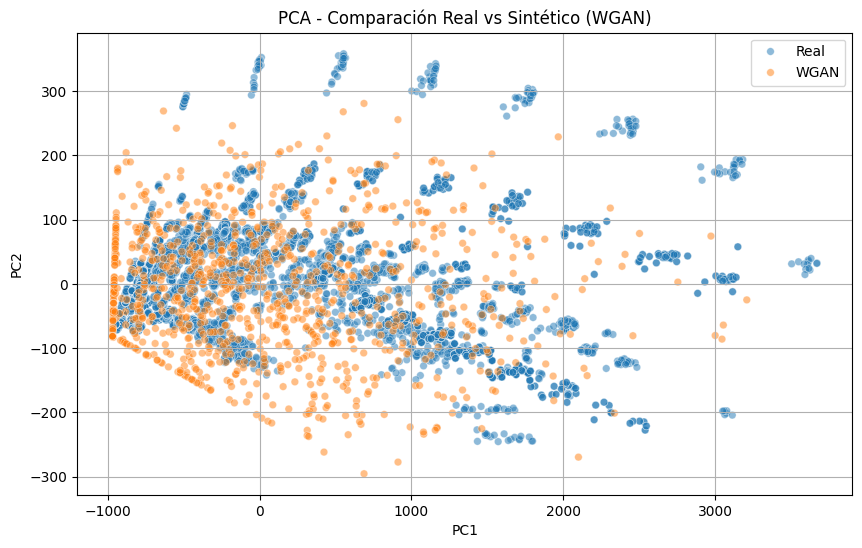

✔️ Varianza explicada por PC1 + PC2: 99.89%


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Etiquetar el origen de los datos
df_real = df_ruido.copy()
df_real['origen'] = 'Real'

df_sint = df_sintetico_wgan.copy()
df_sint['origen'] = 'WGAN'

# Combinar
df_pca_input = pd.concat([df_real, df_sint], ignore_index=True)

# Seleccionar solo columnas numéricas
X = df_pca_input.select_dtypes(include=[np.number]).drop(columns=['origen'], errors='ignore')

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Armar DataFrame con resultados
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['origen'] = df_pca_input['origen'].values

# Gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='origen', alpha=0.5, s=30)
plt.title('PCA - Comparación Real vs Sintético (WGAN)')
plt.grid(True)
plt.legend()
plt.show()

# Varianza explicada
print(f"✔️ Varianza explicada por PC1 + PC2: {pca.explained_variance_ratio_.sum():.2%}")


SCRIPT DE COMPARACIÓN VARIABLE A VARIABLE

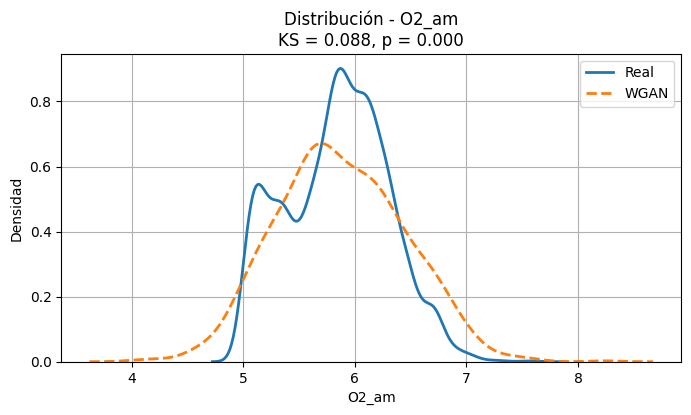

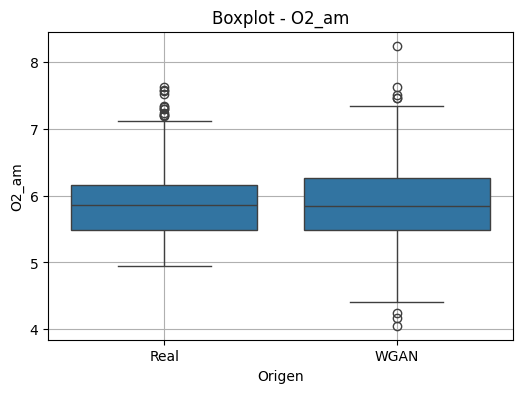

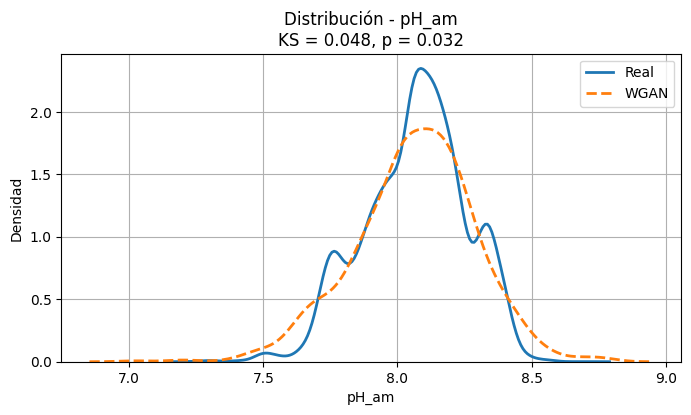

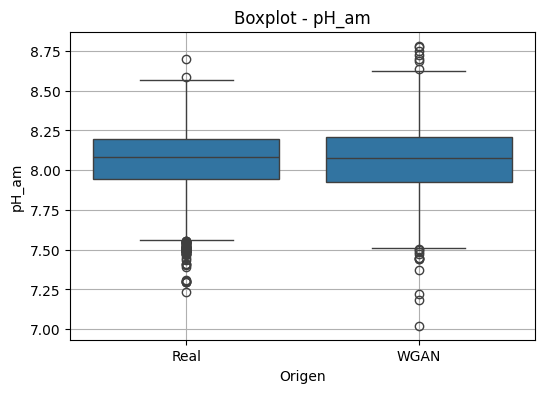

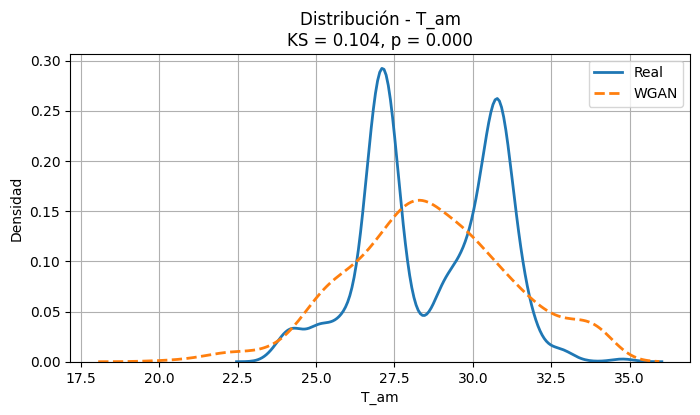

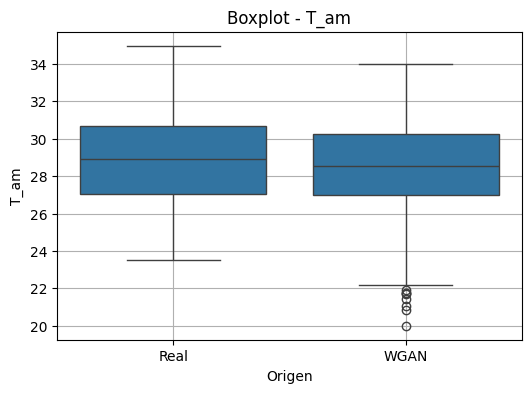

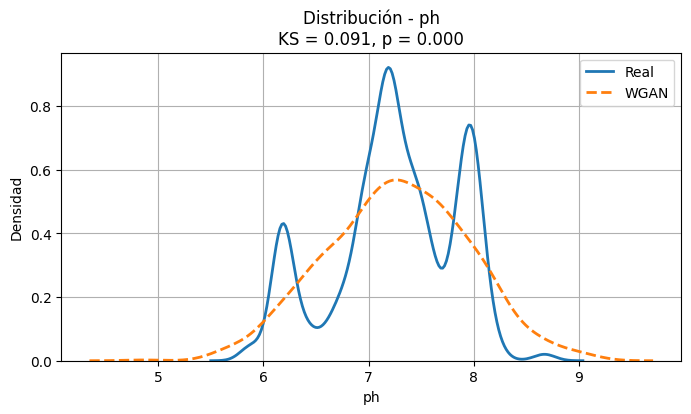

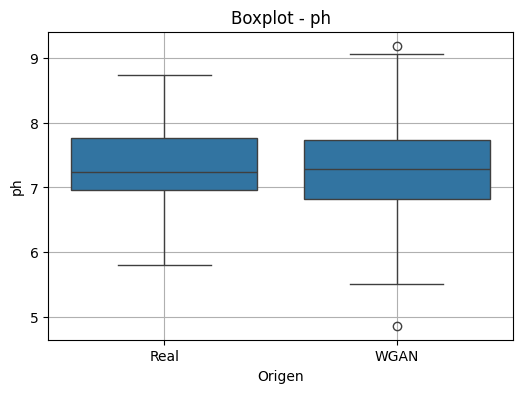

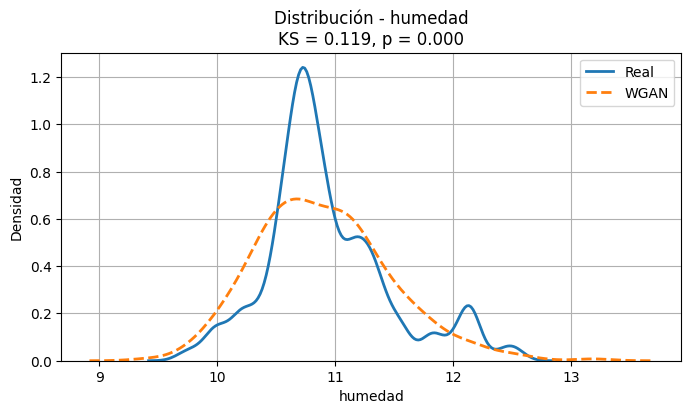

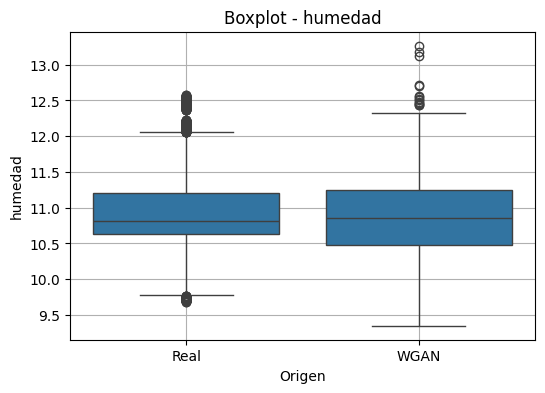

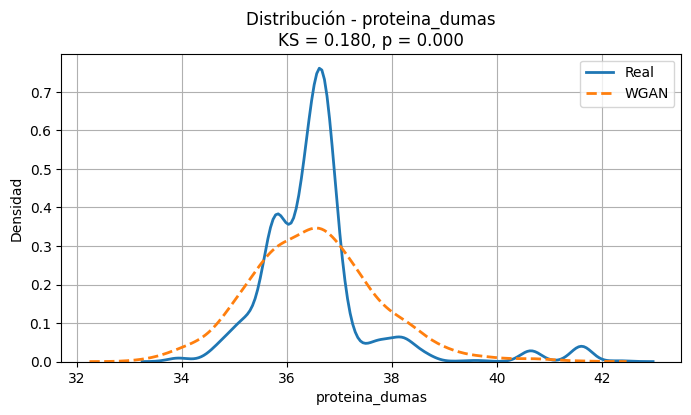

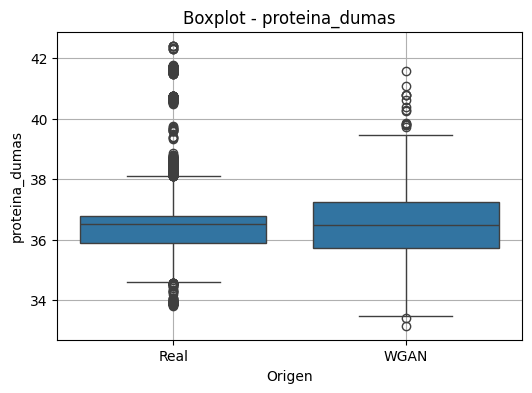

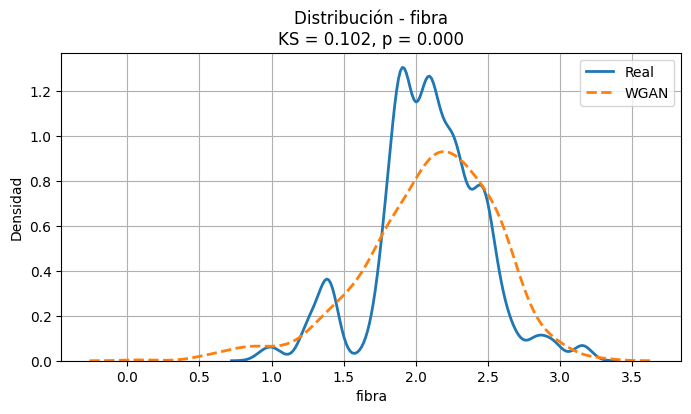

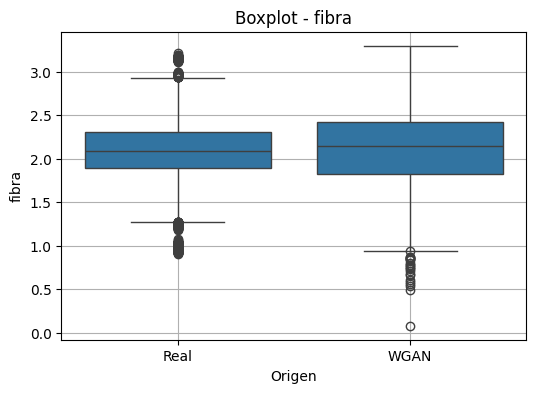

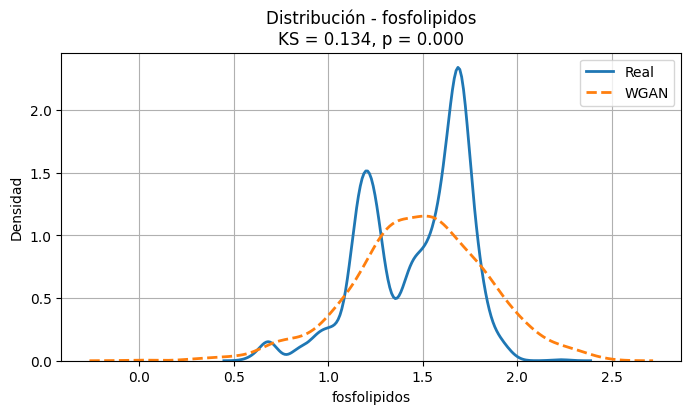

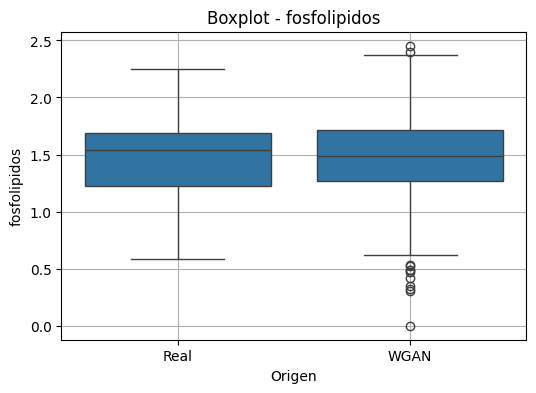

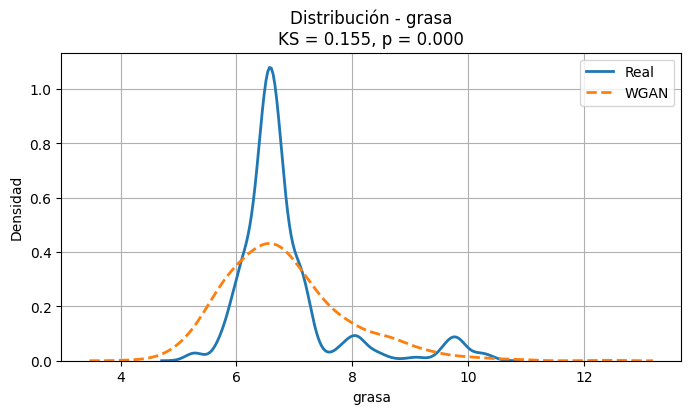

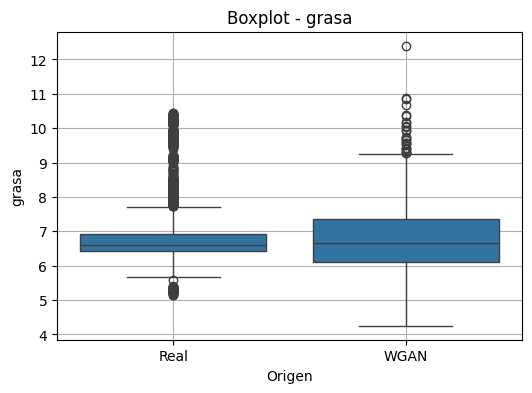

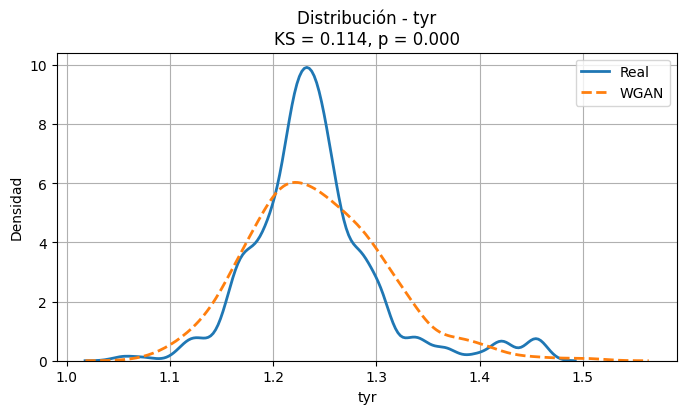

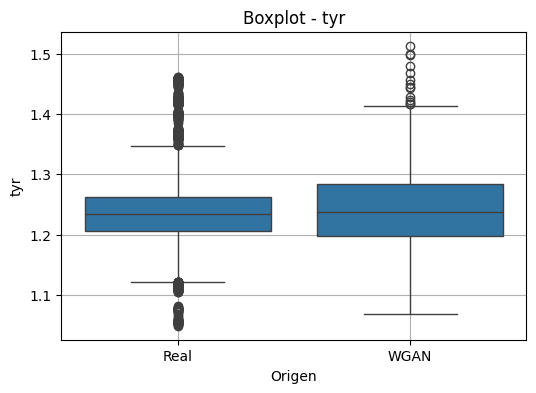

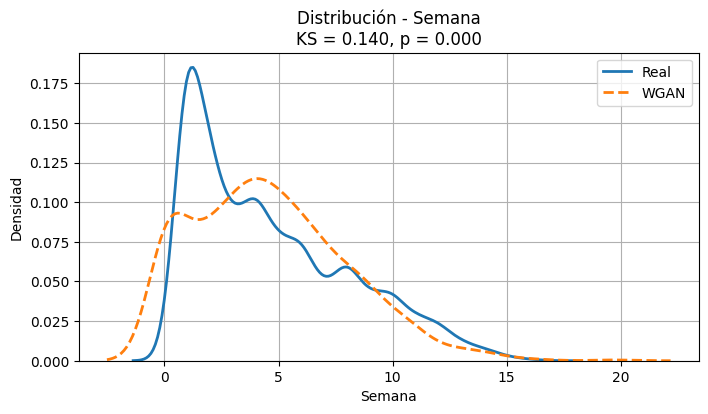

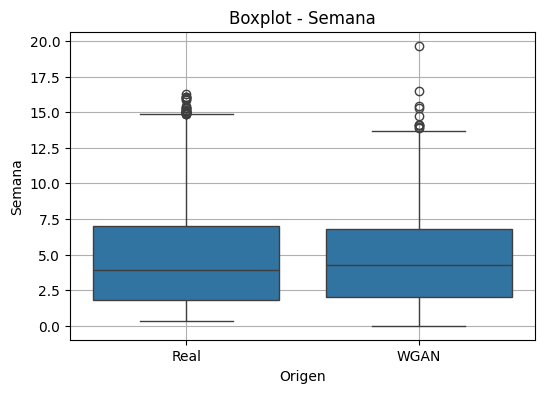

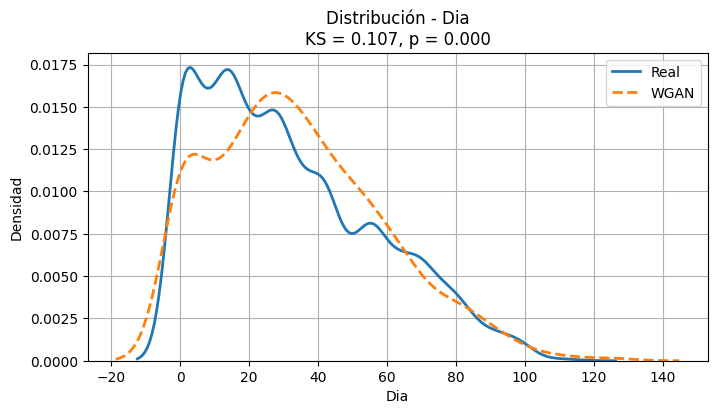

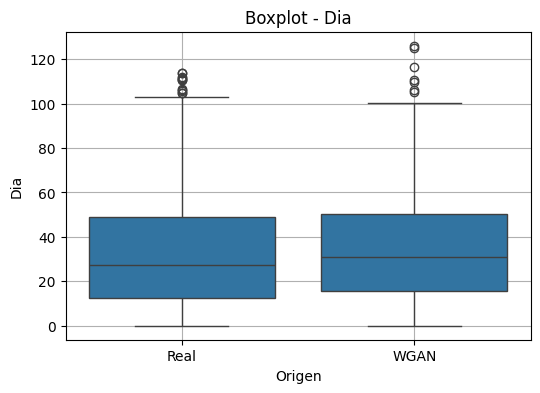

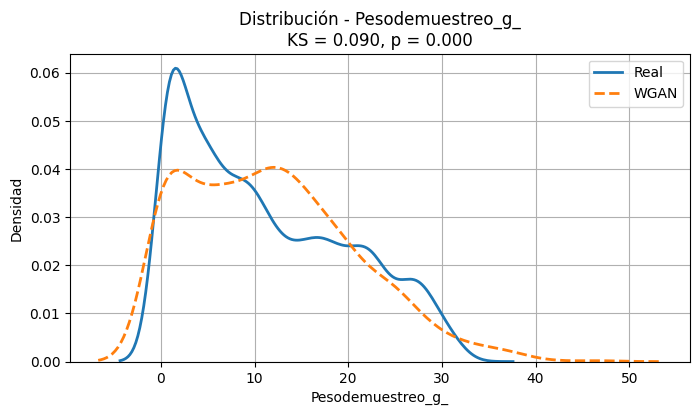

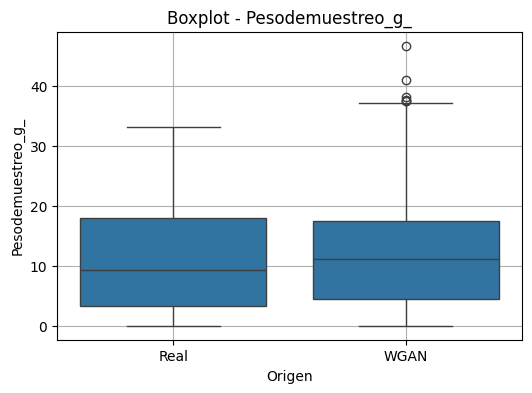

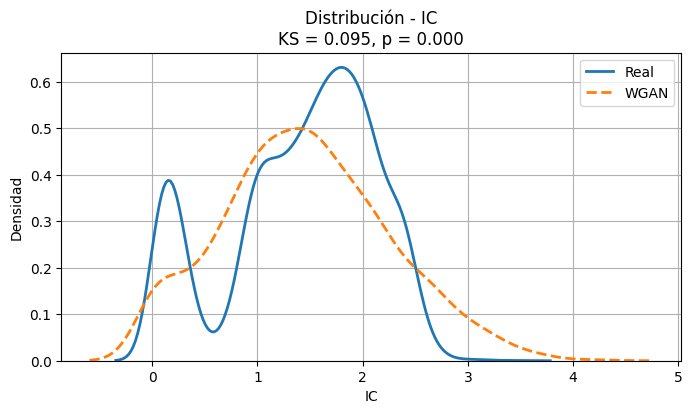

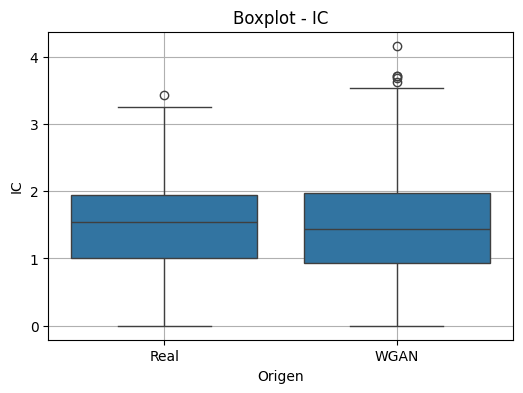

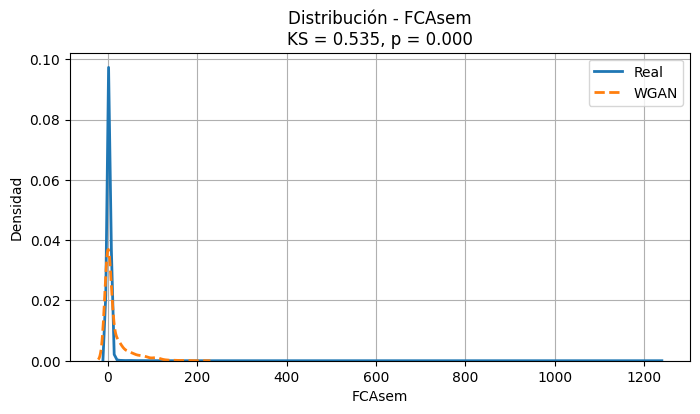

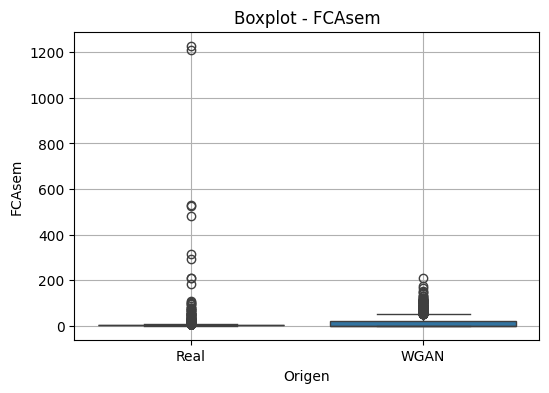

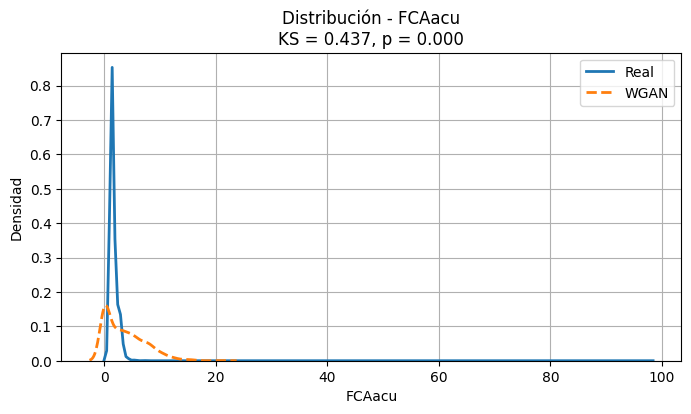

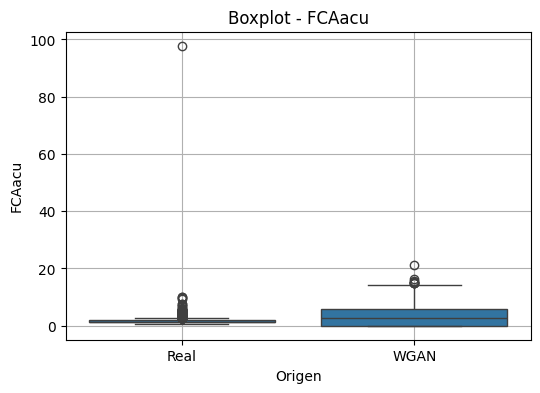

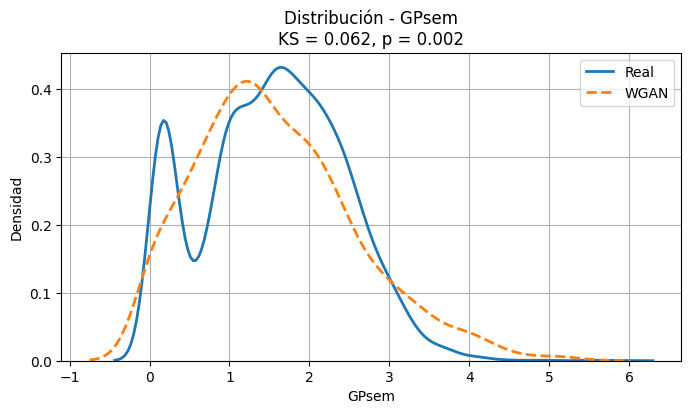

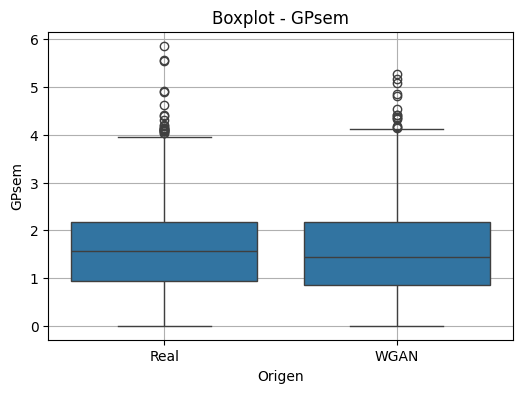

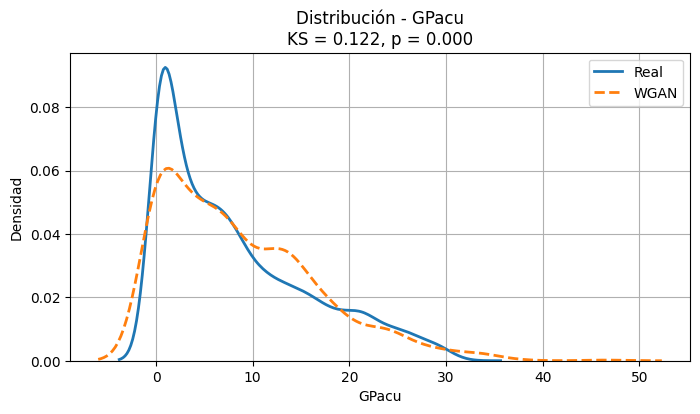

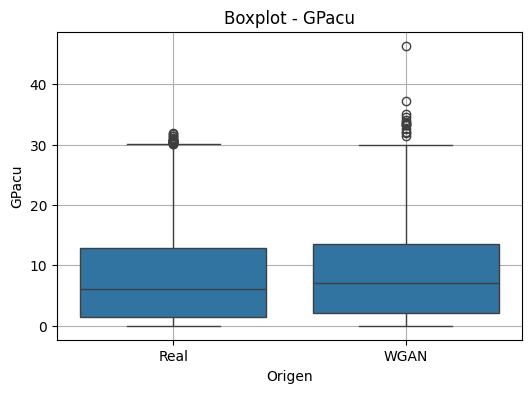

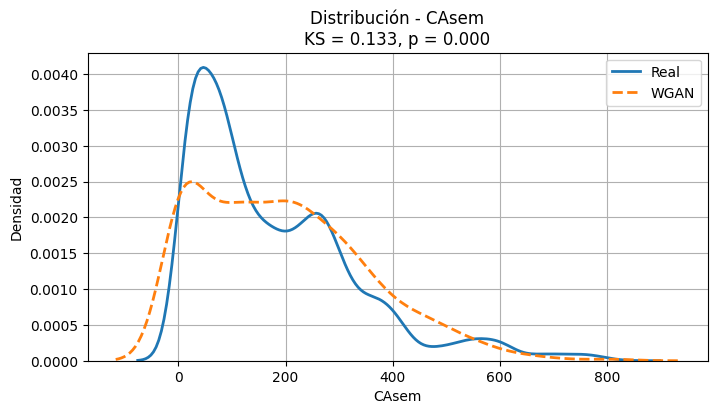

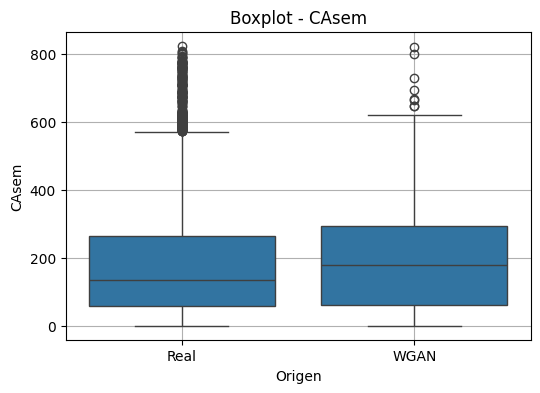

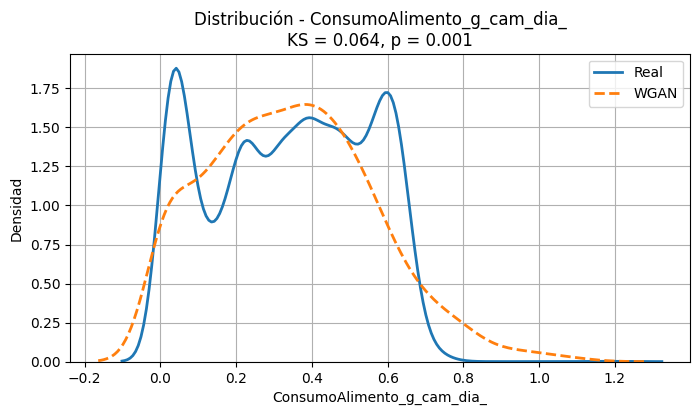

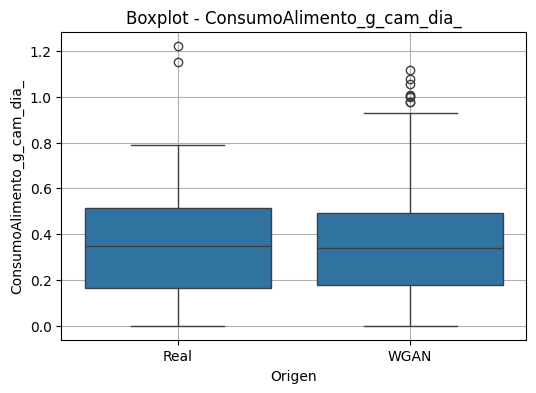

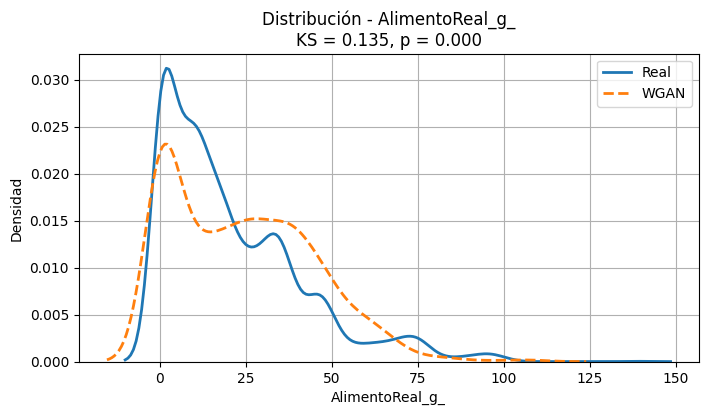

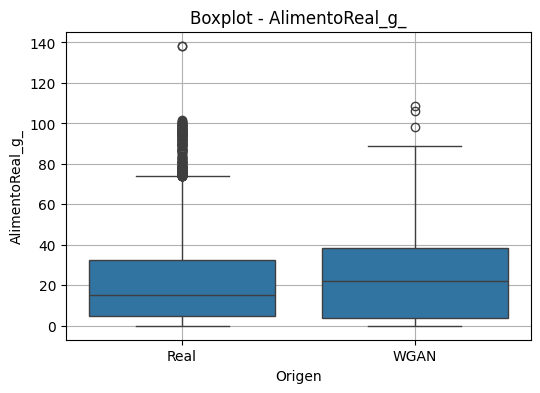

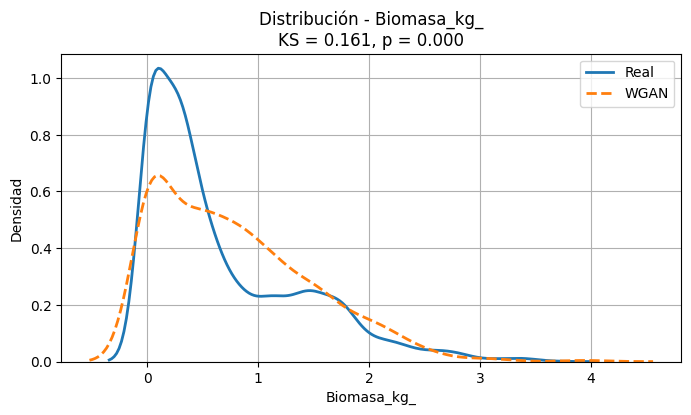

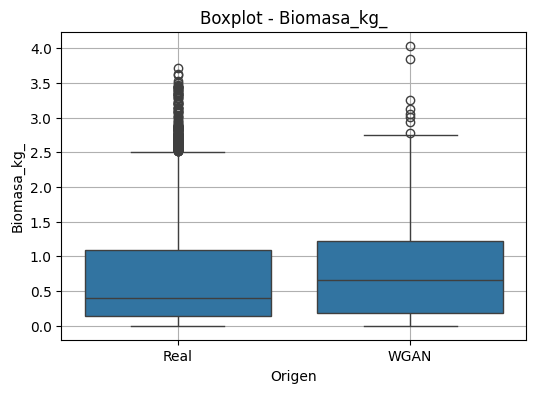

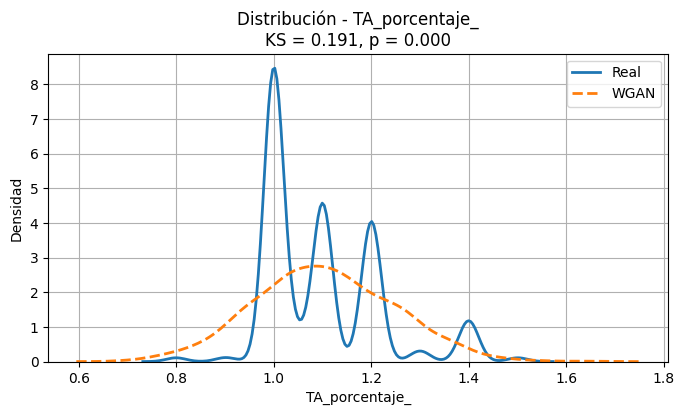

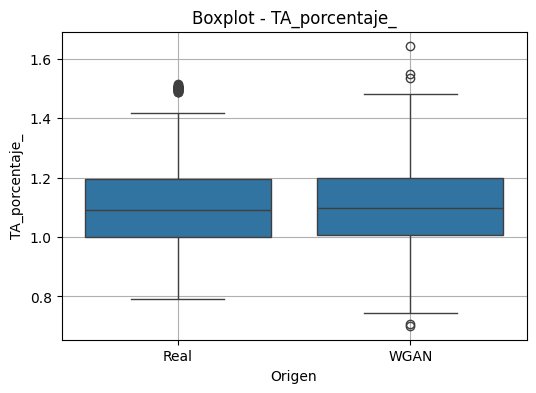

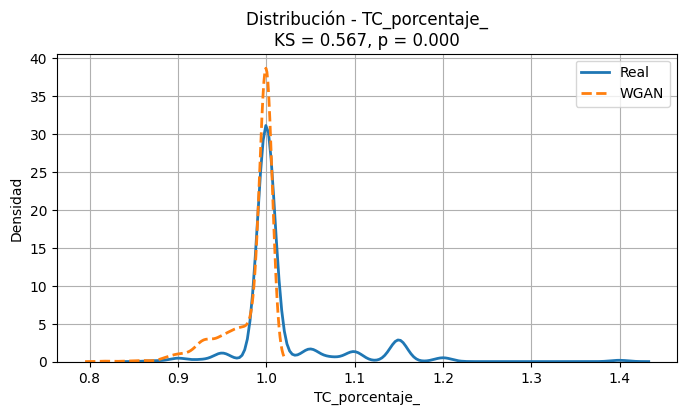

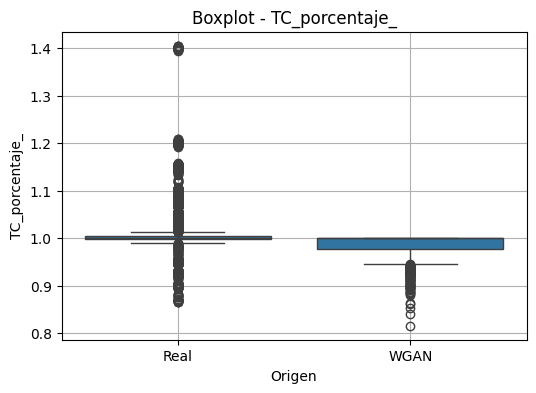

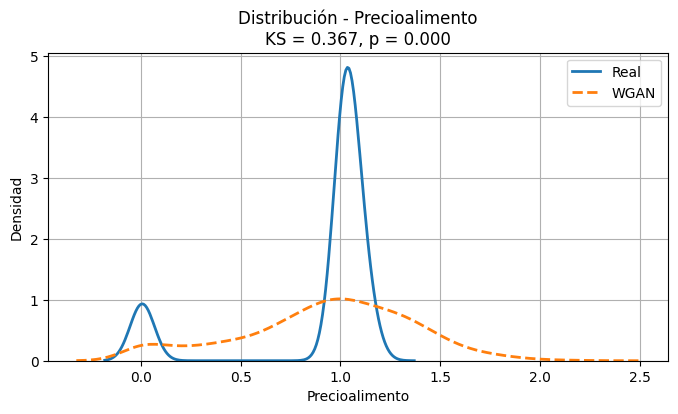

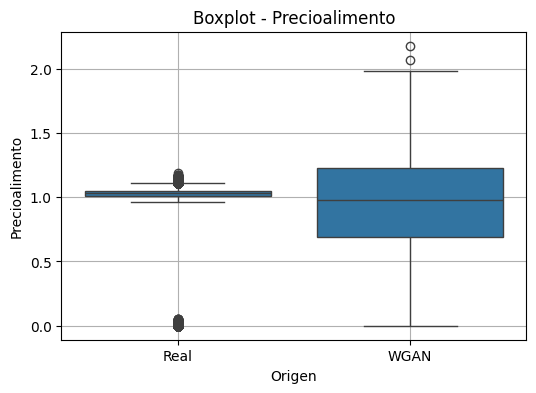

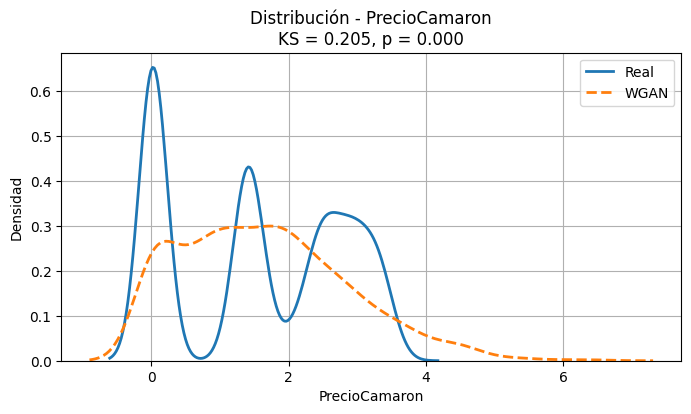

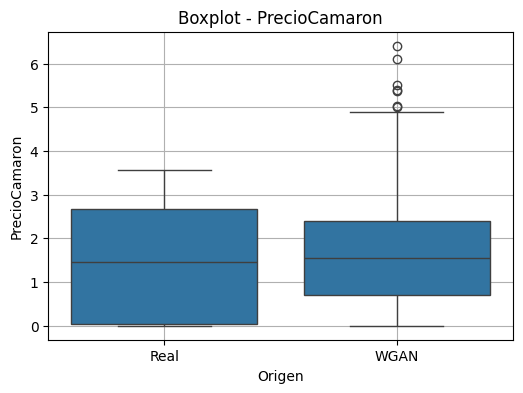

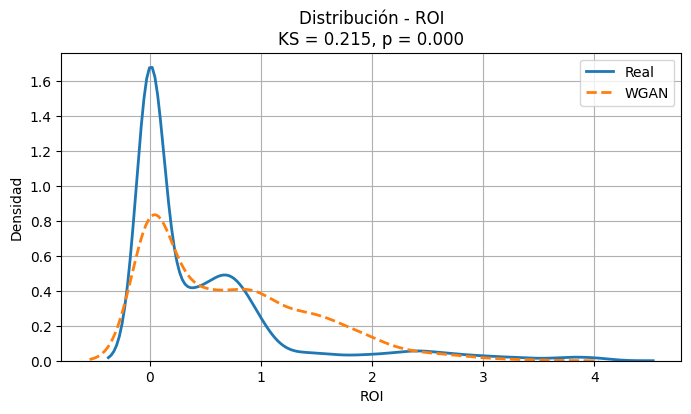

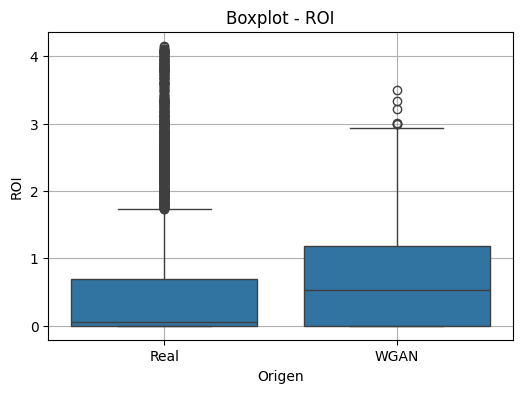

Resumen del KS-test Real vs WGAN (ordenado por disimilitud):


,Variable,KS_Statistic,P_value
0,TC_porcentaje_,0.567240,4.234483e-269
1,FCAsem,0.535068,2.916142e-237
2,FCAacu,0.436650,1.717547e-154
3,Precioalimento,0.366589,1.220870e-107
4,ROI,0.215260,1.001765e-36
5,PrecioCamaron,0.204929,2.678558e-33
6,TA_porcentaje_,0.190673,7.437033e-29
7,proteina_dumas,0.179862,1.050956e-25
8,Biomasa_kg_,0.160767,1.336036e-20
9,grasa,0.155312,2.996231e-19


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# Variables numéricas comunes
vars_comunes = df_ruido.select_dtypes(include='number').columns.intersection(df_sintetico_wgan.columns)

# Inicializar tabla para guardar resultados del KS-test
ks_resultados = []

for var in vars_comunes:
    real_vals = df_ruido[var].dropna()
    sint_vals = df_sintetico_wgan[var].dropna()

    # KS test
    ks_stat, p_value = ks_2samp(real_vals, sint_vals)
    ks_resultados.append({
        'Variable': var,
        'KS_Statistic': ks_stat,
        'P_value': p_value
    })

    # 📈 KDE plot
    plt.figure(figsize=(8, 4))
    sns.kdeplot(real_vals, label='Real', linewidth=2)
    sns.kdeplot(sint_vals, label='WGAN', linestyle='--', linewidth=2)
    plt.title(f'Distribución - {var}\nKS = {ks_stat:.3f}, p = {p_value:.3f}')
    plt.xlabel(var)
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 📊 Boxplot
    df_temp = pd.DataFrame({
        var: pd.concat([real_vals, sint_vals], ignore_index=True),
        'Origen': ['Real'] * len(real_vals) + ['WGAN'] * len(sint_vals)
    })

    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_temp, x='Origen', y=var)
    plt.title(f'Boxplot - {var}')
    plt.grid(True)
    plt.show()

# Mostrar resumen de KS-test
df_ks = pd.DataFrame(ks_resultados)
df_ks_sorted = df_ks.sort_values(by='KS_Statistic', ascending=False).reset_index(drop=True)

# Mostrar resumen de KS-test en Colab
print("Resumen del KS-test Real vs WGAN (ordenado por disimilitud):")
display(df_ks_sorted)


Script WGAN-GP CPU


In [ ]:
# PASO 1: Librerías
!pip install -q torch torchvision
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.autograd import grad

# PASO 2: Leer datos y preparar
ruta_ruido = "/content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/df_ruido.xlsx"
df_ruido = pd.read_excel(ruta_ruido)

# Selección de columnas numéricas
cols_objetivo = df_ruido.select_dtypes(include=[np.number]).columns.tolist()
df_focus = df_ruido[cols_objetivo].dropna().reset_index(drop=True)

# Escalar
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_focus)
data_tensor = torch.tensor(data_scaled, dtype=torch.float32)

# PASO 3: Redes
input_dim = data_tensor.shape[1]
latent_dim = 10

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, z):
        return self.model(z)

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

# PASO 4: Penalización de gradiente
def gradient_penalty(critic, real_data, fake_data):
    alpha = torch.rand(real_data.size(0), 1)
    alpha = alpha.expand_as(real_data)
    interpolated = alpha * real_data + (1 - alpha) * fake_data
    interpolated.requires_grad_(True)

    prob_interpolated = critic(interpolated)
    gradients = grad(
        outputs=prob_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(prob_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gradients = gradients.view(real_data.size(0), -1)
    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return penalty

# PASO 5: Entrenamiento
generator = Generator()
critic = Critic()

g_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.9))
c_optimizer = torch.optim.Adam(critic.parameters(), lr=1e-4, betas=(0.5, 0.9))

epochs = 2000
batch_size = 64
lambda_gp = 10
n_critic = 5

for epoch in range(epochs):
    for _ in range(n_critic):
        idx = torch.randint(0, len(data_tensor), (batch_size,))
        real_data = data_tensor[idx]
        z = torch.randn(batch_size, latent_dim)
        fake_data = generator(z).detach()

        critic_real = critic(real_data)
        critic_fake = critic(fake_data)

        gp = gradient_penalty(critic, real_data, fake_data)
        c_loss = -(critic_real.mean() - critic_fake.mean()) + lambda_gp * gp

        c_optimizer.zero_grad()
        c_loss.backward()
        c_optimizer.step()

    z = torch.randn(batch_size, latent_dim)
    fake_data = generator(z)
    g_loss = -critic(fake_data).mean()

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Critic Loss: {c_loss.item():.4f} | Generator Loss: {g_loss.item():.4f}")

# PASO 6: Generar y guardar
z = torch.randn(1000, latent_dim)
fake_samples = generator(z).detach().numpy()
fake_samples = scaler.inverse_transform(fake_samples)

# 🚨 Forzar valores positivos
fake_samples = np.clip(fake_samples, a_min=0, a_max=None)

df_sintetico_wgangp = pd.DataFrame(fake_samples, columns=cols_objetivo)

#Aumentando df_ruido con df_sintetico_wgangp_todas_columnas

df_augmented_wgangp_todas_columnas = pd.concat([df_ruido, df_sintetico_wgangp], ignore_index=True)

# PASO 6: Guardar en Excel
ruta = '../data/data_processed/df_augmented_wgangp_todas_columnas.xlsx'
df_augmented_wgangp_todas_columnas.to_excel(ruta, index=False)
print(f"✅ Archivo WGAN guardado en: {ruta}")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 0 | Critic Loss: 8.3111 | Generator Loss: -0.0217
Epoch 500 | Critic Loss: -0.0624 | Generator Loss: 0.3935
Epoch 1000 | Critic Loss: -0.0436 | Generator Loss: 0.4814
Epoch 1500 | Critic Loss: -0.0551 | Generator Loss: 0.6839
✅ Archivo WGAN guardado en: /content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/df_augmented_wgangp_todas_columnas.xlsx


PCA: WGAN-GP


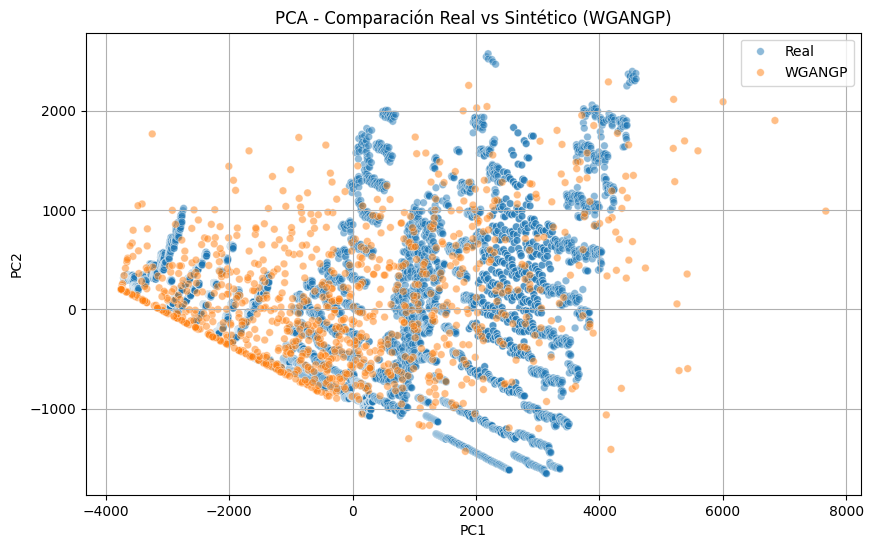

✔️ Varianza explicada por PC1 + PC2: 99.90%


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Etiquetar el origen de los datos
df_real = df_ruido.copy()
df_real['origen'] = 'Real'

df_sint = df_sintetico_wgangp.copy()
df_sint['origen'] = 'WGANGP'

# Combinar
df_pca_input = pd.concat([df_real, df_sint], ignore_index=True)

# Seleccionar solo columnas numéricas
X = df_pca_input.select_dtypes(include=[np.number]).drop(columns=['origen'], errors='ignore')

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Armar DataFrame con resultados
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['origen'] = df_pca_input['origen'].values

# Gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='origen', alpha=0.5, s=30)
plt.title('PCA - Comparación Real vs Sintético (WGANGP)')
plt.grid(True)
plt.legend()
plt.show()

# Varianza explicada
print(f"✔️ Varianza explicada por PC1 + PC2: {pca.explained_variance_ratio_.sum():.2%}")

WGAN-GP Embedding por semana

In [ ]:
# PASO 1: Librerías
!pip install -q torch torchvision
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.autograd import grad

# PASO 2: Leer datos
ruta_ruido = "../data/data_processed/df_ruido.xlsx"
df_ruido = pd.read_excel(ruta_ruido)

# Asegurar tipo entero en Semana
df_ruido['Semana'] = df_ruido['Semana'].astype(int)
n_semanas = df_ruido['Semana'].nunique()

# Columnas numéricas
cols_objetivo = df_ruido.select_dtypes(include=[np.number]).columns.tolist()
df_focus = df_ruido[cols_objetivo].dropna().reset_index(drop=True)

# Escalado
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_focus)
data_tensor = torch.tensor(data_scaled, dtype=torch.float32)
semana_tensor = torch.tensor(df_focus['Semana'].values[:len(data_tensor)], dtype=torch.long)

# Dimensiones
input_dim = data_tensor.shape[1]
latent_dim = 10

# PASO 3: Generator con embedding por semana
class Generator(nn.Module):
    def __init__(self, n_semanas, embedding_dim=4):
        super().__init__()
        self.embedding = nn.Embedding(n_semanas + 1, embedding_dim)
        self.model = nn.Sequential(
            nn.Linear(latent_dim + embedding_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, z, semana):
        emb = self.embedding(semana)
        x = torch.cat([z, emb], dim=1)
        return self.model(x)

# PASO 4: Crítico y penalización de gradiente
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

def gradient_penalty(critic, real_data, fake_data):
    alpha = torch.rand(real_data.size(0), 1)
    alpha = alpha.expand_as(real_data)
    interpolated = alpha * real_data + (1 - alpha) * fake_data
    interpolated.requires_grad_(True)

    prob_interpolated = critic(interpolated)
    gradients = grad(
        outputs=prob_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(prob_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gradients = gradients.view(real_data.size(0), -1)
    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return penalty

# PASO 5: Entrenamiento
generator = Generator(n_semanas=n_semanas)
critic = Critic()

g_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.9))
c_optimizer = torch.optim.Adam(critic.parameters(), lr=1e-4, betas=(0.5, 0.9))

epochs = 2000
batch_size = 64
lambda_gp = 10
n_critic = 5

for epoch in range(epochs):
    for _ in range(n_critic):
        idx = torch.randint(0, len(data_tensor), (batch_size,))
        real_data = data_tensor[idx]
        semana_batch = semana_tensor[idx]
        z = torch.randn(batch_size, latent_dim)
        fake_data = generator(z, semana_batch).detach()

        critic_real = critic(real_data)
        critic_fake = critic(fake_data)
        gp = gradient_penalty(critic, real_data, fake_data)
        c_loss = -(critic_real.mean() - critic_fake.mean()) + lambda_gp * gp

        c_optimizer.zero_grad()
        c_loss.backward()
        c_optimizer.step()

    z = torch.randn(batch_size, latent_dim)
    semana_batch = semana_tensor[torch.randint(0, len(semana_tensor), (batch_size,))]
    fake_data = generator(z, semana_batch)
    g_loss = -critic(fake_data).mean()

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Critic Loss: {c_loss.item():.4f} | Generator Loss: {g_loss.item():.4f}")

# PASO 6: Generar datos para todas las semanas (1 a 16)
synthetic_dfs = []
for semana in range(1, 17):
    semana_idx = torch.tensor([semana] * 1000, dtype=torch.long)
    z = torch.randn(1000, latent_dim)
    fake_samples = generator(z, semana_idx).detach().numpy()
    fake_samples = scaler.inverse_transform(fake_samples)
    fake_samples = np.clip(fake_samples, a_min=0, a_max=None)
    df_sintetico = pd.DataFrame(fake_samples, columns=cols_objetivo)
    df_sintetico['Semana'] = semana
    synthetic_dfs.append(df_sintetico)

# Concatenar todos los resultados
df_sintetico_todas = pd.concat(synthetic_dfs, ignore_index=True)

# Guardar
ruta = "...data/data_processed/df_sintetico_todas_semanas.xlsx"
df_sintetico_todas.to_excel(ruta, index=False)
print(f"✅ Datos sintéticos por semana 1 a 16 guardados en: {ruta}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 0 | Critic Loss: 8.4731 | Generator Loss: 0.0962
Epoch 500 | Critic Loss: -0.0828 | Generator Loss: 1.2139
Epoch 1000 | Critic Loss: -0.0472 | Generator Loss: 1.0934
Epoch 1500 | Critic Loss: -0.0107 | Generator Loss: 0.9953
✅ Datos sintéticos por semana 1 a 16 guardados en: /content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/df_sintetico_todas_semanas.xlsx


Comparación variable por variable entre datos reales y sintéticos wgangp

✅ Comparación completada.


,Variable,KS_Statistic,P_Value,Same_Distribution
16,FCAsem,0.524727,2.604788e-224,False
25,TC_porcentaje_,0.464513,2.413728e-173,False
17,FCAacu,0.426219,7.359687e-145,False
26,ROI,0.410053,1.055951e-133,False
24,TA_porcentaje_,0.330212,9.534360e-86,False
12,sobrevivencia_limpia,0.261000,2.771937e-53,False
14,PesoInicial,0.219650,1.018387e-37,False
1,O2_am,0.189750,3.397220e-28,False
3,T_am,0.182630,3.869568e-26,False
21,CAacum,0.149000,1.642813e-17,False


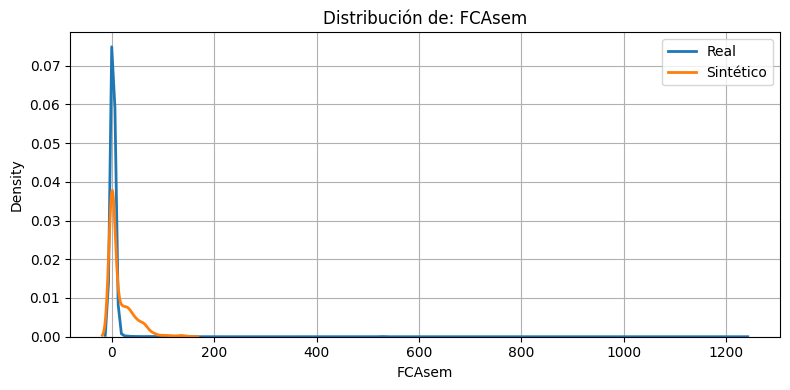

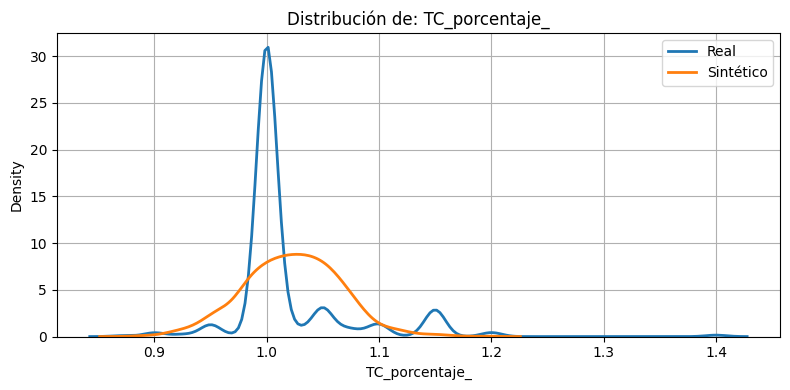

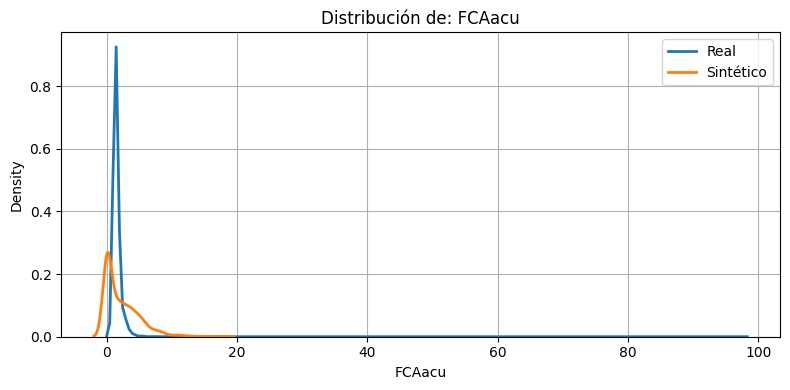

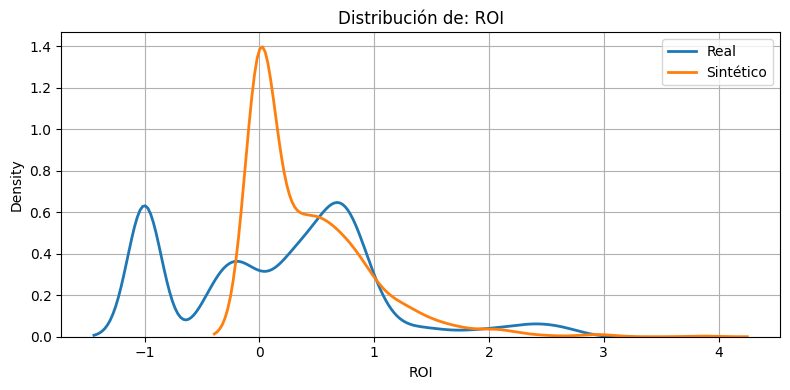

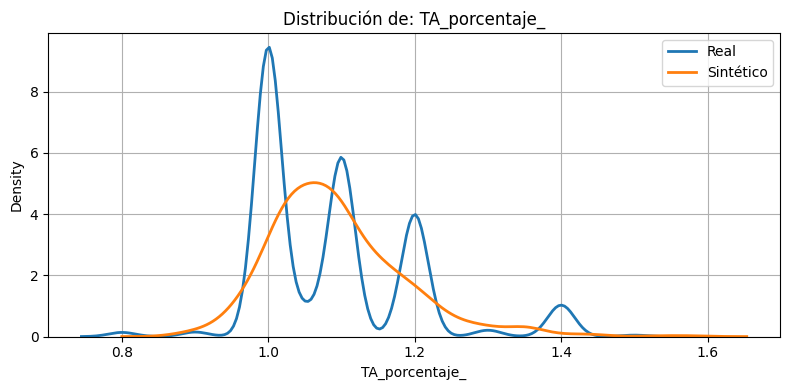

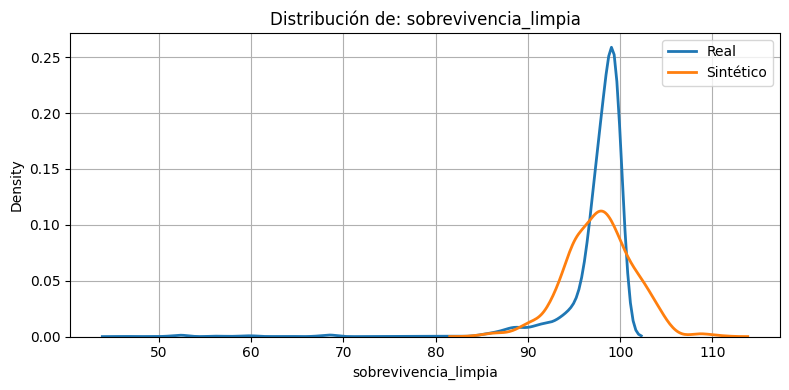

In [ ]:
from scipy.stats import ks_2samp
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# Comparar distribuciones variable por variable
# ===============================
ks_resultados = []

for col in cols_objetivo:
    real_vals = df_ruido[col].dropna()
    sint_vals = df_sintetico_wgangp[col].dropna()

    # KS Test
    ks_stat, ks_pval = ks_2samp(real_vals, sint_vals)

    # Guardar resultados
    ks_resultados.append({
        'Variable': col,
        'KS_Statistic': ks_stat,
        'P_Value': ks_pval,
        'Same_Distribution': ks_pval > 0.05
    })

# Crear DataFrame de resultados
df_ks = pd.DataFrame(ks_resultados).sort_values(by='KS_Statistic', ascending=False)
print("✅ Comparación completada.")
display(df_ks)

# ===============================
# Visualizar distribuciones de las 6 variables con mayor diferencia
# ===============================
top_dif = df_ks.head(6)['Variable'].tolist()

for var in top_dif:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(df_ruido[var], label='Real', linewidth=2)
    sns.kdeplot(df_sintetico_wgangp[var], label='Sintético', linewidth=2)
    plt.title(f'Distribución de: {var}')
    plt.xlabel(var)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Script completo de comparación

In [ ]:
from scipy.stats import ks_2samp
import pandas as pd

# Diccionario con tus modelos
modelos_sinteticos = {
    "GAN": df_sintetico_gan,
    "WGAN": df_sintetico_wgan,
    "WGAN-GP": df_sintetico_wgangp,
    "WGAN-GP-embedding": df_sintetico_todas
}

# Selección de columnas comunes con df_ruido
cols_comunes = df_ruido.select_dtypes(include=[float, int]).columns.intersection(
    set.intersection(*[set(df.columns) for df in modelos_sinteticos.values()])
).tolist()

# Comparación KS por variable y modelo
resultados = []
for modelo, df_sint in modelos_sinteticos.items():
    for col in cols_comunes:
        real = df_ruido[col].dropna()
        sint = df_sint[col].dropna()
        ks_stat, p_val = ks_2samp(real, sint)
        resultados.append({
            "Modelo": modelo,
            "Variable": col,
            "KS_Statistic": ks_stat,
            "P_Value": p_val,
            "Same_Distribution": p_val > 0.05
        })

# Crear DataFrame de resultados
df_ks = pd.DataFrame(resultados)

# Resumen general por modelo
df_resumen = df_ks.groupby("Modelo").agg({
    "KS_Statistic": "mean",
    "Same_Distribution": "mean"
}).rename(columns={
    "KS_Statistic": "KS_Stat_Medio",
    "Same_Distribution": "% Variables Similares"
}).sort_values("KS_Stat_Medio")

print("📊 Resumen KS por Modelo:")
print(df_resumen)



📊 Resumen KS por Modelo:
                   KS_Stat_Medio  % Variables Similares
Modelo                                                 
WGAN-GP                 0.176704                    0.0
WGAN                    0.186084                    0.0
WGAN-GP-embedding       0.203944                    0.0
GAN                     0.403319                    0.0


📊 Resumen KS por Modelo:
                   KS_Stat_Medio  % Variables Similares
Modelo                                                 
WGAN-GP                 0.176704                    0.0
WGAN                    0.186084                    0.0
WGAN-GP-embedding       0.203944                    0.0
GAN                     0.403319                    0.0


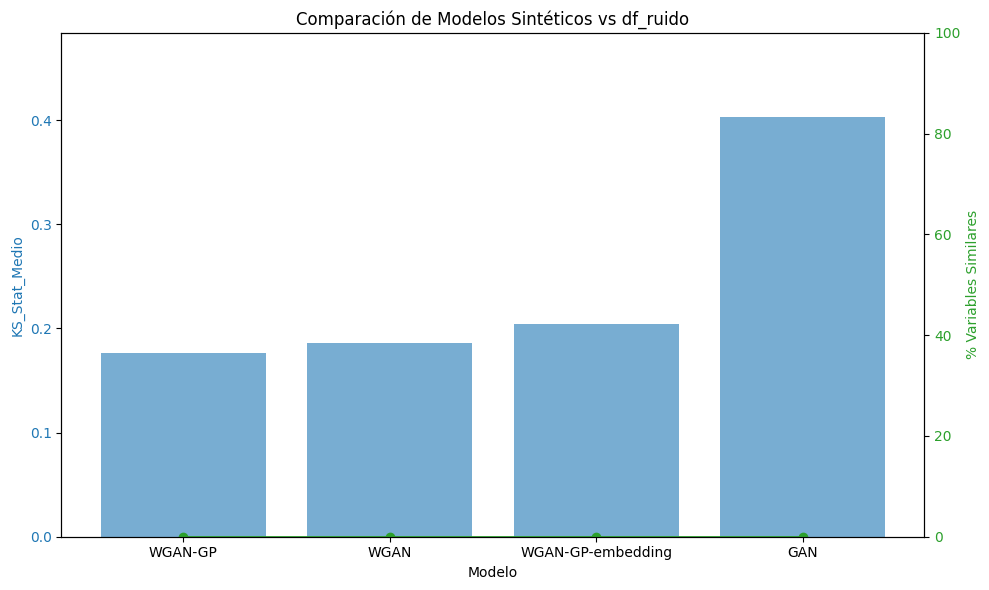

📁 Gráfico guardado en: /content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/KS_comparacion_modelos.png


In [ ]:
import matplotlib.pyplot as plt

# Mostrar resumen en consola
print("📊 Resumen KS por Modelo:")
print(df_resumen)

# Crear gráfico de barras
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Modelo')
ax1.set_ylabel('KS_Stat_Medio', color=color)
ax1.bar(df_resumen.index, df_resumen['KS_Stat_Medio'], color=color, alpha=0.6, label='KS_Stat_Medio')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, df_resumen['KS_Stat_Medio'].max() * 1.2)

# Crear segundo eje para el % de variables similares
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('% Variables Similares', color=color)
ax2.plot(df_resumen.index, df_resumen['% Variables Similares'] * 100, color=color, marker='o', linewidth=2, label='% Variables Similares')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 100)

plt.title('Comparación de Modelos Sintéticos vs df_ruido')
fig.tight_layout()

# Guardar el gráfico
ruta_plot = "/data/outputs/KS_comparacion_modelos.png"
plt.savefig(ruta_plot)
plt.show()

print("📁 Gráfico guardado en:", ruta_plot)
